![My Image](C:/Users/USER/Downloads/josh-withers-5W3JkWpA_wU-unsplash.jpg)


![My Image](https://images.unsplash.com/photo-1574901200090-ca061722bdb9?q=80&w=1470&auto=format&fit=crop)


# COMPREHENSIVE SUPERSTORE SALES ANALYSIS: TRENDS, INSIGHTS, AND STRATEGIC RECOMMENDATIONS


## **INTRODUCTION**  

This analysis examines a retail superstore dataset containing **1,993 rows and 25 columns**, covering key metrics such as **Sales, Quantity Sold, Profit, Order Date, Product Name, and Region**. The objective is to identify trends and insights that can support data-driven decision-making.  

## **Key Steps in the Analysis**  

### 🔹 **Data Cleaning:**  
- Removed duplicate records to maintain data integrity.  
- Converted **Order Date** and **Ship Date** to datetime format for accurate time-based analysis.  
- Ensured **Sales** and **Quantity** were in numeric format for precise calculations.  

### 🔹 **Feature Engineering:**  
- Extracted **Month** and **Year** from the Order Date to analyze trends over time.  

### 🔹 **Analysis Methods:**  
- Aggregated data to compute total sales, profit, and key performance metrics.  
- Used **line graphs** to analyze sales trends over time.  
- Applied **bar charts** to compare product categories, customer segments, and regional performance.  

By structuring and analyzing this dataset, we uncover key insights into **sales performance, profitability trends, and customer behavior**, enabling strategic recommendations for business growth. 🚀


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


##### import libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## DATA CLEANING AND PREPARATION

In [ ]:
# Load dataset
file_path = r'C:\Users\USER\Downloads\Superstore 2014 _1 - Sheet1.csv'
df = pd.read_csv(file_path)

# Remove duplicates
df.drop_duplicates(inplace=True)

#  Check for Missing Values
print(df.isnull().sum())

# Check Date Consistency
df[df["Ship Date"] < df["Order Date"]]

#Convert Order ID, Product ID, Customer ID to String
df["Order ID"] = df["Order ID"].astype(str)
df["Product ID"] = df["Product ID"].astype(str)
df["Customer ID"] = df["Customer ID"].astype(str)

# Convert date columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%b-%y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%b-%y', errors='coerce')

# Ensure data types are correct
df["Sales"] = pd.to_numeric(df["Sales"], errors='coerce')
df["Quantity"] = pd.to_numeric(df["Quantity"], errors='coerce')
df["Order Date"] = pd.to_datetime(df["Order Date"], errors='coerce')

# Extract month, year and day for trend analysis
df["order Month"] = df["Order Date"].dt.month
df["order Year"] = df["Order Date"].dt.year
df["order Day"] = df["Order Date"].dt.day

# Extract month, year and day for trend analysis
df["ship Month"] = df["Ship Date"].dt.month
df["ship Year"] = df["Ship Date"].dt.year
df["ship Day"] = df["Ship Date"].dt.day

# Ensure Regions, Cities, and Categories are Consistent
print(df["Region"].unique())  # Check for misspellings
print(df["City"].unique())    # Ensure no duplicate entries due to casing
print(df["Category"].unique())

# Confirm data types
print(df.dtypes)
df

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
['West' 'Central' 'East' 'South']
['Los Angeles' 'Madison' 'West Jordan' 'San Francisco' 'Westland'
 'Gilbert' 'Houston' 'Columbus' 'Bloomington' 'Newark' 'Seattle'
 'San Antonio' 'Chicago' 'Decatur' 'Monroe' 'Hamilton' 'Denver'
 'Charlotte' 'Lakeville' 'Colorado Springs' 'Taylor' 'Lakewood'
 'Hackensack' 'Saint Petersburg' 'Philadelphia' 'New York City'
 'Long Beach' 'Tucson' 'Cincinnati' 'Des Moines' 'Peoria' 'Miami'
 'Wilmington' 'Louisville' 'New Rochelle' 'Jacksonville' 'Concord'
 'San Diego' 'Huntsville' 'Rochester' 'Green Bay' 'Fort Worth' 'Tampa'
 'Laredo' 'Cleveland' 'Jack

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,order Month,order Year,order Day,ship Month,ship Year,ship Day
0,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,48.860,7,0.0,14.1694,6,2014,9,6,2014,14
1,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,7.280,4,0.0,1.9656,6,2014,9,6,2014,14
2,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,907.152,6,0.2,90.7152,6,2014,9,6,2014,14
3,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,18.504,3,0.2,5.7825,6,2014,9,6,2014,14
4,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,114.900,5,0.0,34.4700,6,2014,9,6,2014,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1988,9947,CA-2014-111157,2014-03-02,2014-03-06,Standard Class,NH-18610,Nicole Hansen,Corporate,United States,Philadelphia,...,151.200,3,0.2,32.1300,3,2014,2,3,2014,6
1989,9957,US-2014-143287,2014-11-11,2014-11-17,Standard Class,KN-16705,Kristina Nunn,Home Office,United States,New Rochelle,...,46.350,5,0.0,21.7845,11,2014,11,11,2014,17
1990,9958,US-2014-143287,2014-11-11,2014-11-17,Standard Class,KN-16705,Kristina Nunn,Home Office,United States,New Rochelle,...,223.920,4,0.0,109.7208,11,2014,11,11,2014,17
1991,9959,US-2014-143287,2014-11-11,2014-11-17,Standard Class,KN-16705,Kristina Nunn,Home Office,United States,New Rochelle,...,7.300,2,0.0,2.1900,11,2014,11,11,2014,17


### **Data Cleaning and Preparation: Explanation**  

1. **Loading the Data**  
   - The dataset is imported from a CSV file into a pandas DataFrame.  

2. **Removing Duplicates**  
   - Duplicate rows are removed to maintain data integrity and avoid redundant records.  

3. **Converting Data Types**  
   - The `Order Date` and `Ship Date` columns are converted to datetime format to enable time-based analysis.  
   - `Sales` and `Quantity` are converted to numeric data types to ensure accurate calculations.  

4. **Extracting Date Components for Trend Analysis**  
   - Additional columns (`order Month`, `order Year`, `order Day`) are created from the `Order Date` to facilitate monthly, yearly, and daily trend analysis.  
   - Similarly, `ship Month`, `ship Year`, and `ship Day` are extracted from the `Ship Date` to analyze shipping trends.  

With this cleaned and structured dataset, we can now proceed to analyzing sales performance and identifying key insights. 🚀


## ANALYSE SALES PERFORMANCE

In [ ]:
# Calculate Total Sales, Total Quantity Sold, and Total Profit
total_sales = df['Sales'].sum()
total_quantity_sold = df['Quantity'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity_sold}")
print(f"Total Profit: ${total_profit:,.2f}")

# Identify the Top 5 Best-Selling Products by Total Sales
top_5_products = df.groupby('Product Name').agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=False).head(5)
print("\nTop 5 Best-Selling Products by Total Sales:")
print(top_5_products)

# Identify the Bottom 5 Least-Selling Products by Total Sales
bottom_5_products = df.groupby('Product Name').agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products by Total Sales:")
print(bottom_5_products)

# Identify the Top 5 Best-Selling Products by Quantity Sold
top_5_products_quantity = df.groupby('Product Name').agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=False).head(5)
print("\nTop 5 Best-Selling Products by Quantity Sold:")
print(top_5_products_quantity)

# Identify the Bottom 5 Least-Selling Products by Quantity Sold
bottom_5_products_quantity = df.groupby('Product Name').agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products by Quantity Sold:")
print(bottom_5_products_quantity)

# Determine the Region with the Highest Revenue
region_revenue = df.groupby('Region').agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=False).head(5)
print("\nRegion with the Highest Revenue:")
print(region_revenue)

# Determine the Region with the Highest Profit
region_profit = df.groupby('Region').agg({'Profit': 'sum'}).sort_values(by='Profit', ascending=False).head(5)
print("\nRegion with the Highest Profit:")
print(region_profit)

# Identify the Top 5 Best-Selling Products with Categories and Subcategories
top_5_products_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=False).head(5)
print("\nTop 5 Best-Selling Products with Categories and Subcategories:")
print(top_5_products_details)

# Identify the Bottom 5 Least-Selling Products with Categories and Subcategories
bottom_5_products_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products with Categories and Subcategories:")
print(bottom_5_products_details)

# Identify the Top 5 Best-Selling Products by Quantity with Categories and Subcategories
top_5_products_quantity_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=False).head(5)
print("\nTop 5 Best-Selling Products by Quantity with Categories and Subcategories:")
print(top_5_products_quantity_details)

# Identify the Bottom 5 Least-Selling Products by Quantity with Categories and Subcategories
bottom_5_products_quantity_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products by Quantity with Categories and Subcategories:")
print(bottom_5_products_quantity_details)



Total Sales: $484,247.50
Total Quantity Sold: 7581
Total Profit: $49,543.97

Top 5 Best-Selling Products by Total Sales:
                                                        Sales
Product Name                                                 
Cisco TelePresence System EX90 Videoconferencin...  22638.480
Lexmark MX611dhe Monochrome Laser Printer           11219.934
HP Designjet T520 Inkjet Large Format Printer -...   9624.945
Ibico EPK-21 Electric Binding System                 9449.950
High Speed Automatic Electric Letter Opener          8187.650

Bottom 5 Least-Selling Products by Total Sales:
                                                    Sales
Product Name                                             
Avery Round Ring Poly Binders                       0.852
Avery Binder Labels                                 1.167
Universal Recycled Hanging Pressboard Report Bi...  1.234
Computer Printout Index Tabs                        1.344
Presstex Flexible Ring Binders                  

## Sales Analysis Summary

### Total Sales: $484,247.50  

### Total Quantity Sold: 7,581 units  

### Total Profit: $49,543.97  

## Key Insights

### Top-Selling Products by Sales  
- The **Cisco TelePresence System EX90** generated the highest revenue ($22,638.48), highlighting the strong demand for premium technology products.  
- High-value technology products such as **printers and videoconferencing systems** contributed the most to total sales.  

### Top-Selling Products by Quantity  
- **Staple Envelopes** had the highest sales volume (54 units), but its total revenue was significantly lower than high-priced items.  
- Everyday office supplies like **staples and résumé paper** were among the most frequently purchased items, indicating steady demand for consumables.  

### Regional Performance  
- The **West region recorded the highest total sales ($147,883.03) and profit ($20,065.69)**, indicating strong demand and effective cost management.  
- The **Central region, despite having similar sales figures to the South, had the lowest profit ($539.55)**, suggesting **higher operational costs or lower pricing strategies that affected profitability**.  


## IDENTIFYING TRENDS

###  Monthly Sales Trend

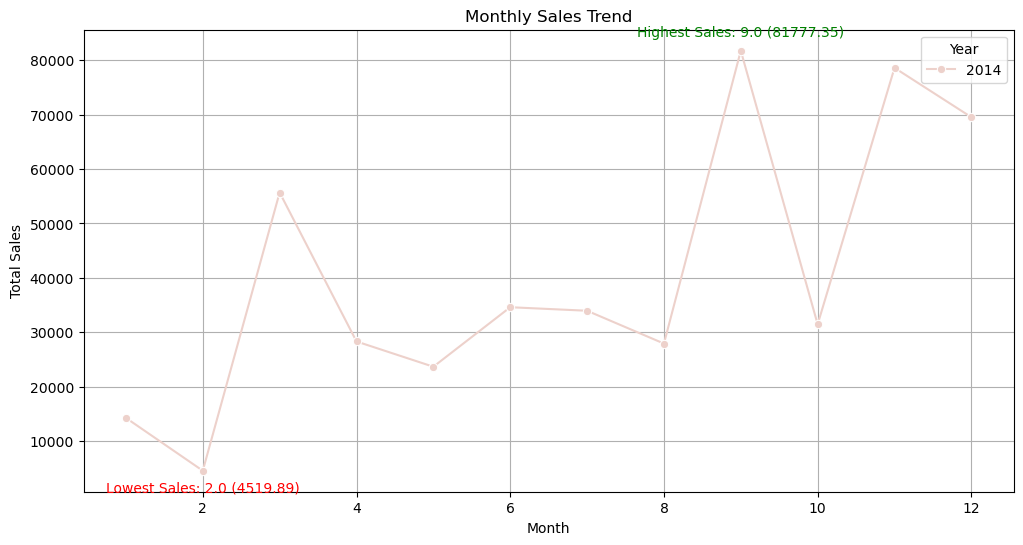

In [ ]:
# Group by year and month to get monthly sales
monthly_sales = df.groupby(["order Year", "order Month"])["Sales"].sum().reset_index()

# Find the months with the highest and lowest sales
highest_sales = monthly_sales.loc[monthly_sales["Sales"].idxmax()]
lowest_sales = monthly_sales.loc[monthly_sales["Sales"].idxmin()]

# Plot the monthly sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x="order Month", y="Sales", hue="order Year", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Year")
plt.grid(True)

# Display the highest and lowest sales months
plt.annotate(f"Highest Sales: {highest_sales['order Month']} ({highest_sales['Sales']:.2f})",
             (highest_sales["order Month"], highest_sales["Sales"]),
             textcoords="offset points", xytext=(0,10), ha='center', color="green", fontsize=10)

plt.annotate(f"Lowest Sales: {lowest_sales['order Month']} ({lowest_sales['Sales']:.2f})",
             (lowest_sales["order Month"], lowest_sales["Sales"]),
             textcoords="offset points", xytext=(0,-15), ha='center', color="red", fontsize=10)

plt.show()


### SEPTEMBER ANALYSIS AND FEBRUARY ANALYSIS

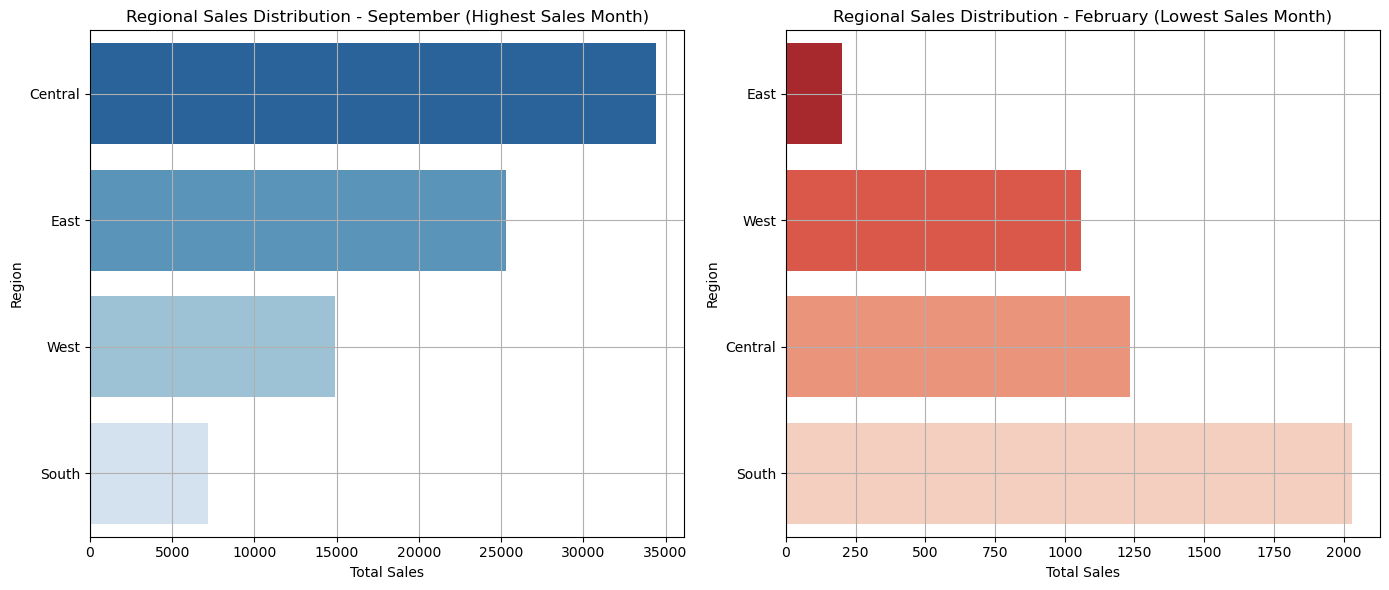

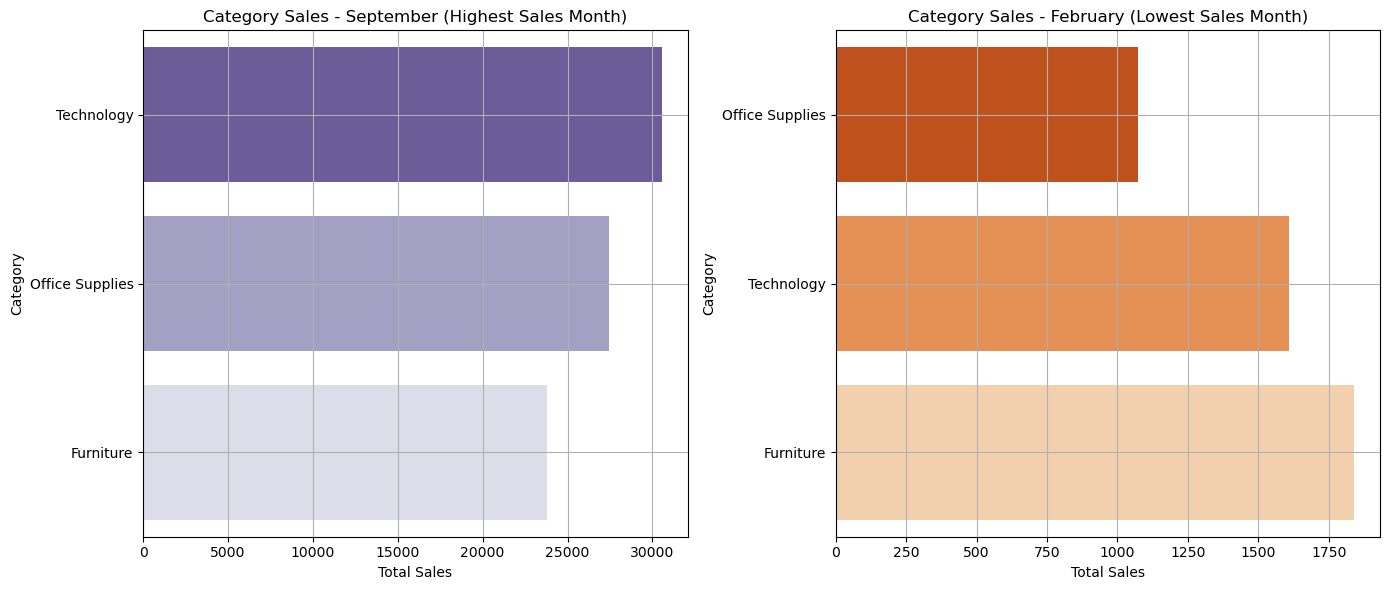

In [ ]:
# SEPTEMBER ANALYSIS
# Filter September sales data
september_sales = df[df["order Month"] == 9]

# Group by region for September
september_region_sales = september_sales.groupby("Region")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)

# Group by category for September
september_category_sales = september_sales.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)


# FEBRUARY ANALYSIS
# Filter February sales data
february_sales = df[df["order Month"] == 2]

# Group by category for February (lowest sales category)
february_category_sales = february_sales.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending=True)

# Group by region for February (lowest sales region)
february_region_sales = february_sales.groupby("Region")["Sales"].sum().reset_index().sort_values("Sales", ascending=True)


# PLOT REGIONAL SALES FOR SEPTEMBER & FEBRUARY
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=september_region_sales, x="Sales", y="Region", palette="Blues_r")
plt.title("Regional Sales Distribution - September (Highest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(data=february_region_sales, x="Sales", y="Region", palette="Reds_r")
plt.title("Regional Sales Distribution - February (Lowest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.grid(True)

plt.tight_layout()
plt.show()


# PLOT CATEGORY SALES FOR SEPTEMBER & FEBRUARY
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=september_category_sales, x="Sales", y="Category", palette="Purples_r")
plt.title("Category Sales - September (Highest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(data=february_category_sales, x="Sales", y="Category", palette="Oranges_r")
plt.title("Category Sales - February (Lowest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.grid(True)

plt.tight_layout()
plt.show()


### FILTER DATA FOR SEPTEMBER

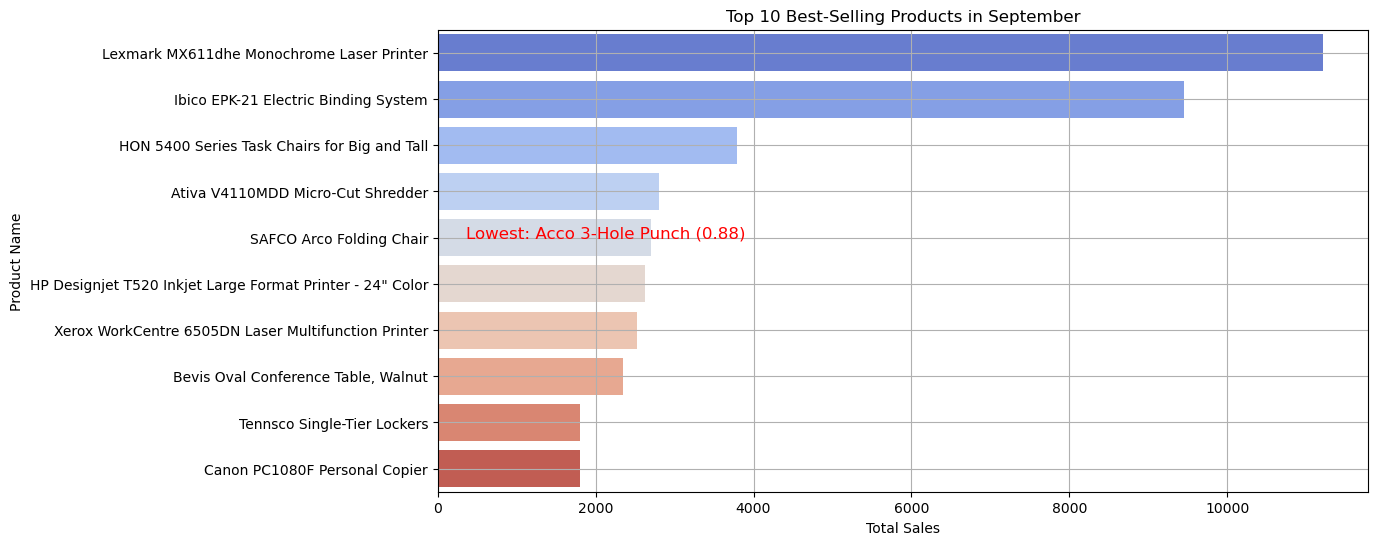

In [ ]:
# Filter data for September
september_sales = df[df["order Month"] == 9]

# Group by product name and sum the sales
product_sales_september = september_sales.groupby("Product Name")["Sales"].sum().reset_index()

# Sort to get highest and lowest selling products
top_product = product_sales_september.nlargest(1, "Sales")
lowest_product = product_sales_september.nsmallest(1, "Sales")

# Plot sales distribution of products in September
plt.figure(figsize=(12, 6))
sns.barplot(data=product_sales_september.sort_values("Sales", ascending=False).head(10),
            x="Sales", y="Product Name", palette="coolwarm")

plt.title("Top 10 Best-Selling Products in September")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.grid(True)

# Annotate highest and lowest selling products
plt.annotate(f"Highest: {top_product['Product Name'].values[0]} ({top_product['Sales'].values[0]:,.2f})",
             xy=(top_product['Sales'].values[0], top_product.index.values[0]),
             xytext=(20, 0), textcoords="offset points", color="green", fontsize=12)

plt.annotate(f"Lowest: {lowest_product['Product Name'].values[0]} ({lowest_product['Sales'].values[0]:,.2f})",
             xy=(lowest_product['Sales'].values[0], lowest_product.index.values[0]),
             xytext=(20, 0), textcoords="offset points", color="red", fontsize=12)

plt.show()


### FILTER DATA FOR FEBRUARY

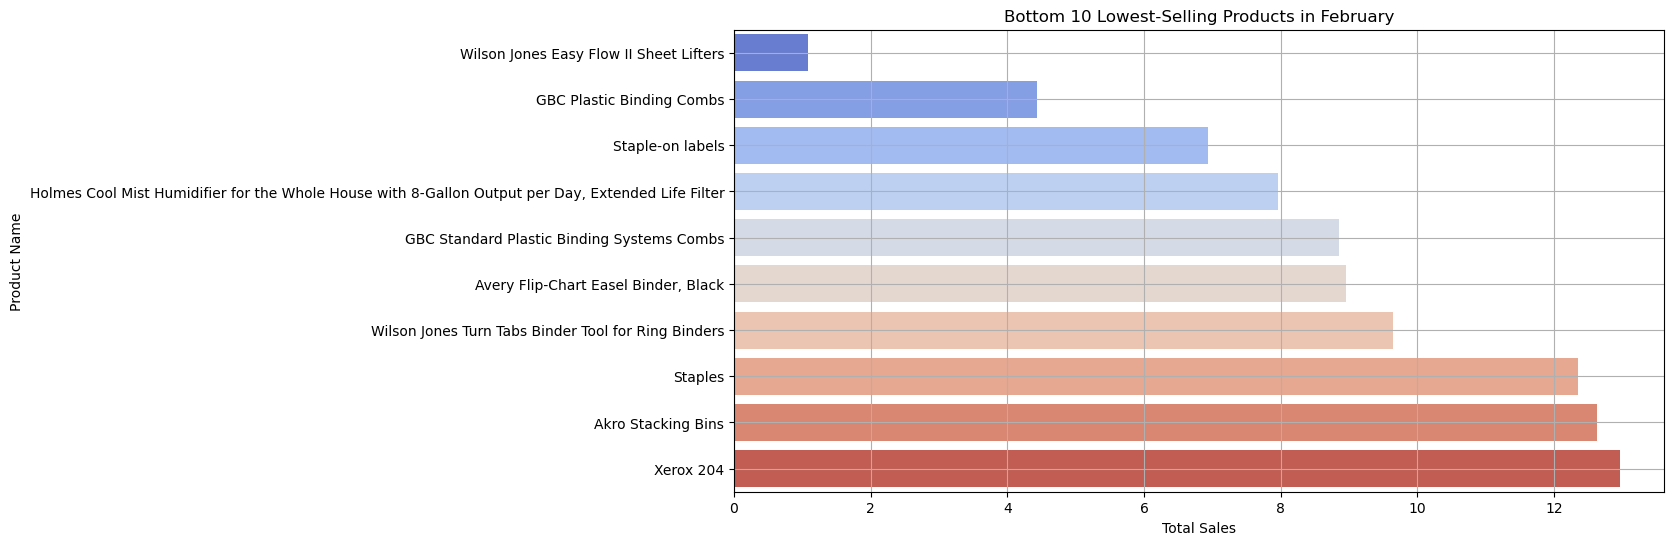

In [ ]:
# Filter data for February
february_sales = df[df["order Month"] == 2]

# Group by product name and sum the sales
product_sales_february = february_sales.groupby("Product Name")["Sales"].sum().reset_index()

# Identify the lowest-selling product
lowest_product_february = product_sales_february.nsmallest(1, "Sales")

# Plot sales distribution of lowest-selling products in February
plt.figure(figsize=(12, 6))
sns.barplot(data=product_sales_february.sort_values("Sales", ascending=True).head(10),
            x="Sales", y="Product Name", palette="coolwarm")

plt.title("Bottom 10 Lowest-Selling Products in February")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.grid(True)

# Annotate lowest-selling product
plt.annotate(f"Lowest: {lowest_product_february['Product Name'].values[0]} ({lowest_product_february['Sales'].values[0]:,.2f})",
             xy=(lowest_product_february['Sales'].values[0], lowest_product_february.index.values[0]),
             xytext=(20, 0), textcoords="offset points", color="red", fontsize=12)

plt.show()


### FILTER SEPTEMBER 2014 SALES DATA

In [ ]:
# Filter September 2014 sales data
september_sales = df[(df["order Month"] == 9) & (df["order Year"] == 2014)]
top_segment_sept = september_sales.groupby("Segment")["Sales"].sum().idxmax()

# Filter February 2014 sales data
february_sales = df[(df["order Month"] == 2) & (df["order Year"] == 2014)]
bottom_segment_feb = february_sales.groupby("Segment")["Sales"].sum().idxmin()

print(f"📈 The highest spending customer segment in September 2014: {top_segment_sept}")
print(f"📉 The lowest spending customer segment in February 2014: {bottom_segment_feb}")


📈 The highest spending customer segment in September 2014: Consumer
📉 The lowest spending customer segment in February 2014: Home Office


### THE MOST SHIPPING MODE IN SEPTEMBER 2014

In [ ]:
# Find most used shipping mode in September 2014
top_shipping_sept = september_sales["Ship Mode"].value_counts().idxmax()

# Find least used shipping mode in February 2014
bottom_shipping_feb = february_sales["Ship Mode"].value_counts().idxmin()

print(f"🚀 The most used shipping mode in September 2014: {top_shipping_sept}")
print(f"🐢 The least used shipping mode in February 2014: {bottom_shipping_feb}")


🚀 The most used shipping mode in September 2014: Standard Class
🐢 The least used shipping mode in February 2014: Same Day


### THE TOTAL PROFIT FOR SEPTEMBER 2014

In [ ]:
# Calculate total profit for September 2014
total_profit_sept = september_sales["Profit"].sum()

# Calculate total profit for February 2014
total_profit_feb = february_sales["Profit"].sum()

print(f"💰 Total profit in September 2014: ${total_profit_sept:.2f}")
print(f"📉 Total profit in February 2014: ${total_profit_feb:.2f}")


💰 Total profit in September 2014: $8328.10
📉 Total profit in February 2014: $862.31


### THE NUMBER OF ORDERS IN SEPTEMBER AND FEBRUARY

In [ ]:
# Calculate the number of orders in September and February
num_orders_sept = september_sales["Order ID"].nunique()
num_orders_feb = february_sales["Order ID"].nunique()

# Calculate average profit per order
avg_profit_per_order_sept = total_profit_sept / num_orders_sept
avg_profit_per_order_feb = total_profit_feb / num_orders_feb

print(f"💰 Average profit per order in September 2014: ${avg_profit_per_order_sept:.2f}")
print(f"📉 Average profit per order in February 2014: ${avg_profit_per_order_feb:.2f}")


💰 Average profit per order in September 2014: $64.06
📉 Average profit per order in February 2014: $30.80


### THE AVERAGE DISCOUNT PER ORDER IN SEPTEMBER AND FEBRUARY 2014

In [ ]:
# Calculate the average discount per order in September 2014
avg_discount_sept = september_sales["Discount"].mean()

# Calculate the average discount per order in February 2014
avg_discount_feb = february_sales["Discount"].mean()

print(f"🔽 Average discount per order in September 2014: {avg_discount_sept:.2%}")
print(f"🔼 Average discount per order in February 2014: {avg_discount_feb:.2%}")


🔽 Average discount per order in September 2014: 16.00%
🔼 Average discount per order in February 2014: 17.61%


### THE AVERAGE QUANTITY PER ORDER IN SEPTEMBER AND FEBRUARY 2014

In [ ]:
# Calculate average quantity per order in September 2014
avg_quantity_sept = september_sales["Quantity"].mean()

# Calculate average quantity per order in February 2014
avg_quantity_feb = february_sales["Quantity"].mean()

print(f"📦 Average quantity per order in September 2014: {avg_quantity_sept:.2f}")
print(f"📦 Average quantity per order in February 2014: {avg_quantity_feb:.2f}")


📦 Average quantity per order in September 2014: 3.73
📦 Average quantity per order in February 2014: 3.46


### THE TOTAL NUMBER OF ORDERS IN SEPTEMBER AND FEBRUARY 2014

In [ ]:
# Total number of orders in September 2014
total_orders_sept = september_sales["Order ID"].nunique()

# Total number of orders in February 2014
total_orders_feb = february_sales["Order ID"].nunique()

print(f"🛒 Total orders in September 2014: {total_orders_sept}")
print(f"📉 Total orders in February 2014: {total_orders_feb}")


🛒 Total orders in September 2014: 130
📉 Total orders in February 2014: 28


## Sales Analysis: September vs February  

### 📊 Key Findings  

#### 🏆 September 2014 (Highest Sales)
- **Top-Selling Region:** Central  
- **Best-Selling Product:** Lexmark MX611dhe Monochrome Laser Printer  
- **Top-Selling Category:** Technology  
- **Total Profit:** $8,328.10  

- **Average Profit per Order:**  $64.06  
- **Total Orders:** 130  

#### 📉 February 2014 (Lowest Sales)
- **Lowest-Selling Region:** East  
- **Lowest-Selling Product:** Wilson Jones Easy Flow II Sheet  
- **Lowest-Selling Category:** Office Supplies  
- **Total Profit:** $862.31  

- **Average Profit per Order:** $30.80  
- **Total Orders:** 28  

### 🔍 Insights  
- **Furniture performed best in February**, while Office Supplies struggled the most.  
- **Technology had a major drop from September to February**, indicating possible **seasonality effects**.  
- The **Central region drove the highest sales in September**, despite having the lowest total profit overall, which suggests that while demand is strong, **high costs or heavy discounts may be reducing profitability**.  
- The **East region struggled the most in February**, indicating **regional variations in seasonal demand**.  

### 🚀 Recommendations  
- **Boost Office Supplies and Technology sales in February** through **promotions, discounts, or bundled offers**.  
- **Capitalize on Furniture's steady demand in low sales months** by maintaining stock and offering financing options.  
- **Target the East region with better marketing strategies in February** to improve sales performance.  
- **Encourage the use of Same Day shipping** with discounts or incentives to drive more sales.  
- **Investigate Consumer segment behaviors in September** to understand why they spend more and replicate similar strategies in other months.  

By leveraging these insights, we can create a **data-driven strategy** to optimize **sales and profitability** across all months. 📈✨


### REGIONAL PROFITABILITY ANALYSIS

In [ ]:
# Filter data for the Central region
central_sales = df[df["Region"] == "Central"]

# Calculate Profit Margin for Central Region
total_sales_central = central_sales["Sales"].sum()
total_profit_central = central_sales["Profit"].sum()
profit_margin_central = (total_profit_central / total_sales_central) * 100

print(f"Central Region Profit Margin: {profit_margin_central:.2f}%")

# Compare with other regions
region_profit_margin = df.groupby("Region").apply(lambda x: (x["Profit"].sum() / x["Sales"].sum()) * 100)
print(region_profit_margin)

# Check if discounts are higher in the Central region (if Discount column exists)
if "Discount" in df.columns:
    avg_discount_central = central_sales["Discount"].mean()
    avg_discount_other_regions = df[df["Region"] != "Central"]["Discount"].mean()

    print(f"Avg Discount in Central: {avg_discount_central:.2f}")
    print(f"Avg Discount in Other Regions: {avg_discount_other_regions:.2f}")

    if avg_discount_central > avg_discount_other_regions:
        print("Higher discounts may be reducing profitability in the Central region.")


Central Region Profit Margin: 0.52%
Region
Central     0.519610
East       13.257343
South      11.439187
West       13.568623
dtype: float64
Avg Discount in Central: 0.26
Avg Discount in Other Regions: 0.13
Higher discounts may be reducing profitability in the Central region.


# Regional Profitability Analysis  

Understanding profitability across regions helps identify areas for improvement. While the **Central region had comparable sales to the South across the full year**, it also had the **lowest profit margin (0.52%)**, significantly lower than other regions, where profitability exceeded **11%**. This raises concerns about **high operational costs or excessive discounting** reducing profitability.  

## Key Findings:  

### **Profitability Variations:**  
- **Central Region Profit Margin:** 0.52%  
- **East:** 13.26%, **South:** 11.44%, **West:** 13.57%  

### **Discounting Impact:**  
- **Avg Discount in Central:** 26% (vs. 13% in other regions)  
- **Higher discounts may be eroding profitability despite strong sales.**  

## Recommendations:  

- **Optimize Discounting Strategies:** Evaluate if the high discounting in the Central region is driving sales or merely reducing profitability.  
- **Prioritize High-Margin Products:** Focus promotions on products with better profit margins instead of broad discounting.  
- **Analyze Consumer Demand Elasticity:** Determine the optimal pricing strategy to balance demand and profitability.  
